In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

In [ ]:
# Generate a synthetic house-price dataset with NumPy
n = 150

size = np.round(np.random.uniform(500, 4500, n), 1)      # sq ft
bedrooms = np.random.randint(1, 7, n)                      # 1-6
age = np.random.randint(0, 51, n)                          # years
distance = np.round(np.random.uniform(0.5, 30, n), 2)      # km from city center

noise = np.random.normal(0, 15000, n)
price = (
    50000
    + size * 120
    + bedrooms * 8000
    - age * 600
    - distance * 1500
    + noise
)
price = np.round(np.maximum(price, 20000), 2)

df = pd.DataFrame({
    "size": size,
    "bedrooms": bedrooms,
    "age": age,
    "distance": distance,
    "price": price,
})

df.to_csv("house_prices.csv", index=False)

In [3]:
# Display the first 5 rows
df.head()

,size,bedrooms,age,distance,price
0,1998.2,1,31,18.67,228460.38
1,4302.9,1,22,28.34,528832.90
2,3428.0,3,32,28.36,421778.17
3,2894.6,6,2,26.08,414765.40
4,1124.1,2,17,19.27,173491.13


In [4]:
# Check for missing values
df.isnull().sum()

size        0
bedrooms    0
age         0
distance    0
price       0
dtype: int64

In [5]:
# Display basic statistics
df.describe()

,size,bedrooms,age,distance,price
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,2391.548667,3.493333,25.506667,15.818600,328060.080133
std,1186.121578,1.736875,14.621280,8.221361,144713.961026
min,522.100000,1.000000,0.000000,1.450000,41091.460000
25%,1359.150000,2.000000,14.250000,8.622500,206424.060000
50%,2292.450000,4.000000,25.000000,15.865000,319051.570000
75%,3498.650000,5.000000,38.000000,22.307500,455962.390000
max,4447.500000,6.000000,50.000000,29.880000,618264.270000


In [6]:
# Separate features (X) and target (y)
X = df[["size", "bedrooms", "age", "distance"]]
y = df["price"]

# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((120, 4), (30, 4))

In [7]:
# Model 1 - Simple Linear Regression (Size -> Price)
X_train_size = X_train[["size"]]
X_test_size = X_test[["size"]]

model_simple = LinearRegression()
model_simple.fit(X_train_size, y_train)

y_pred_simple = model_simple.predict(X_test_size)
y_pred_simple

array([493426.60988239, 307906.45724742, 530724.14252425, 272362.53752159,
       472056.72007104, 181440.73129541, 234847.31500049, 220745.84837909,
       135012.31760795, 259022.9854775 , 239116.45540989, 501650.44976451,
       246312.31530675, 441483.38592103, 239829.99445848, 141760.70386416,
       537992.56571419, 576354.35998786, 544910.26632092, 156938.52599955,
       121418.79403808, 515328.63050963, 195542.19791681, 102310.46019432,
       206390.41023191, 116786.8371633 , 209631.57065604, 244498.23297981,
       419448.33258981, 392853.88567688])

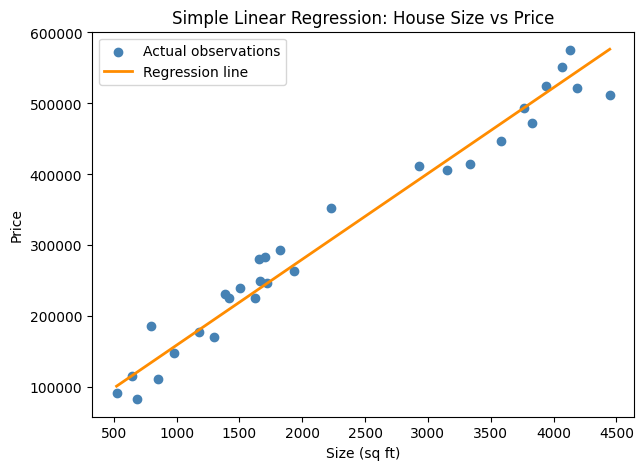

In [8]:
# Scatter plot: actual observations + regression line
plt.scatter(X_test_size, y_test, color="steelblue", label="Actual observations")

size_range = np.linspace(df["size"].min(), df["size"].max(), 100).reshape(-1, 1)
plt.plot(size_range, model_simple.predict(pd.DataFrame(size_range, columns=["size"])),
         color="darkorange", linewidth=2, label="Regression line")

plt.title("Simple Linear Regression: House Size vs Price")
plt.xlabel("Size (sq ft)")
plt.ylabel("Price")
plt.legend()
plt.show()

In [9]:
# Model 2 - Multiple Linear Regression (Size, Bedrooms, Age, Distance -> Price)
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)
y_pred_multi

array([496330.87914106, 347423.48108704, 516125.88031568, 268864.94728204,
       460869.56240187, 186751.61595726, 220570.82459745, 207827.56083019,
       163337.35295787, 268367.84189059, 280807.8329698 , 450097.97652088,
       258064.99361964, 418506.18124187, 223016.62517934, 120560.28863798,
       564399.2141611 , 521849.55553143, 517021.0448899 , 151674.86147626,
       101188.43437636, 515997.31589445, 184982.72520069, 102291.78474403,
       235943.5403219 , 133670.2544531 , 221122.07693948, 279839.322814  ,
       405279.66583372, 406737.83371546])

In [10]:
# Model coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_multi.coef_
})
coeff_df.loc[len(coeff_df)] = ["Intercept", model_multi.intercept_]
coeff_df

,Feature,Coefficient
0,size,118.018402
1,bedrooms,6583.456509
2,age,-693.238574
3,distance,-1628.165536
4,Intercept,65712.021024


In [11]:
# Model 3 - Polynomial Regression (Size -> Price), degree 2 and degree 3
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train_size)
X_test_poly2 = poly2.transform(X_test_size)

model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)
y_pred_poly2 = model_poly2.predict(X_test_poly2)

poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train_size)
X_test_poly3 = poly3.transform(X_test_size)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train)
y_pred_poly3 = model_poly3.predict(X_test_poly3)

y_pred_poly2[:5], y_pred_poly3[:5]

(array([492527.55165662, 311704.12193632, 527206.38517338, 275476.88079156,
        472405.45862627]),
 array([493971.50962235, 310913.21829076, 526984.11187487, 273890.87961471,
        474319.37609226]))

C:\Users\DANIEL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\DANIEL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


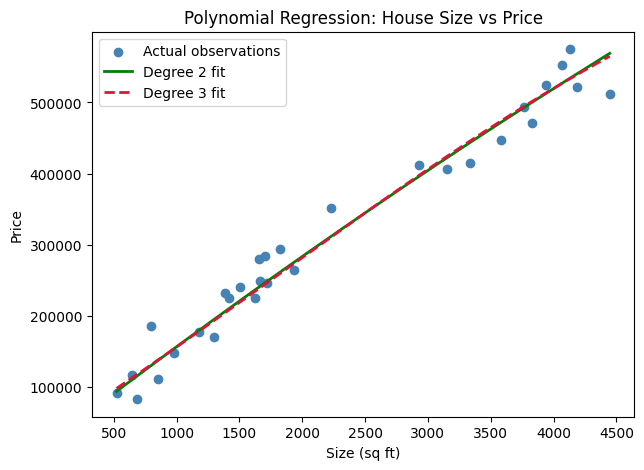

In [12]:
# Plot the data and both regression curves
size_range_sorted = np.linspace(df["size"].min(), df["size"].max(), 200).reshape(-1, 1)

curve_poly2 = model_poly2.predict(poly2.transform(size_range_sorted))
curve_poly3 = model_poly3.predict(poly3.transform(size_range_sorted))

plt.scatter(X_test_size, y_test, color="steelblue", label="Actual observations")
plt.plot(size_range_sorted, curve_poly2, color="green", linewidth=2, label="Degree 2 fit")
plt.plot(size_range_sorted, curve_poly3, color="crimson", linewidth=2, linestyle="--", label="Degree 3 fit")

plt.title("Polynomial Regression: House Size vs Price")
plt.xlabel("Size (sq ft)")
plt.ylabel("Price")
plt.legend()
plt.show()

In [13]:
# Evaluate all models: MAE, MSE, RMSE, R2
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

results = {
    "Linear Regression (Size only)": evaluate(y_test, y_pred_simple),
    "Multiple Linear Regression": evaluate(y_test, y_pred_multi),
    "Polynomial Degree 2": evaluate(y_test, y_pred_poly2),
    "Polynomial Degree 3": evaluate(y_test, y_pred_poly3),
}

comparison_df = pd.DataFrame(results, index=["MAE", "MSE", "RMSE", "R2"]).T
comparison_df

,MAE,MSE,RMSE,R2
Linear Regression (Size only),22840.180853,7.742973e+08,27826.198482,0.964881
Multiple Linear Regression,11493.521658,2.202098e+08,14839.467320,0.990012
Polynomial Degree 2,22190.468877,7.174282e+08,26784.850546,0.967460
Polynomial Degree 3,22481.010659,7.356775e+08,27123.375987,0.966632


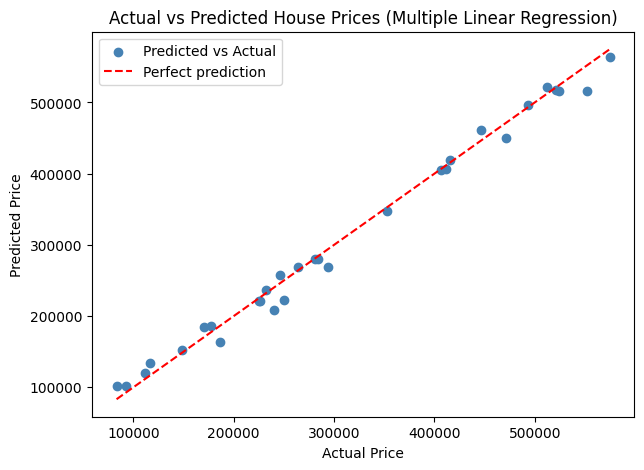

In [14]:
# Actual vs Predicted plot (Multiple Linear Regression) with perfect-prediction line
plt.scatter(y_test, y_pred_multi, color="steelblue", label="Predicted vs Actual")

lims = [min(y_test.min(), y_pred_multi.min()), max(y_test.max(), y_pred_multi.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")

plt.title("Actual vs Predicted House Prices (Multiple Linear Regression)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()